In [40]:
# Importation des bibliothèques nécessaires
# Ces bibliothèques fournissent des outils pour manipuler les données, créer des graphiques, et construire des modèles de machine learning.

import pandas as pd  # Pour manipuler et analyser les données sous forme de tableaux (DataFrames).
import numpy as np  # Pour effectuer des opérations mathématiques et manipuler des tableaux numériques.
import folium  # Pour créer des cartes interactives.
import matplotlib.pyplot as plt  # Pour créer des graphiques et des visualisations.
import cartopy.crs as ccrs  # Pour créer des cartes géographiques.
import cartopy.feature as cfeature  # Pour ajouter des caractéristiques géographiques aux cartes.
import scipy  # Pour des opérations mathématiques et statistiques avancées.
import seaborn as sns  # Pour créer des graphiques statistiques attrayants.
from scipy.stats import shapiro  # Pour effectuer des tests statistiques.
import scipy.stats as stats  # Pour des fonctions statistiques supplémentaires.

from sklearn.impute import KNNImputer  # Pour remplir les valeurs manquantes dans les données.
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score  # Pour diviser les données et optimiser les modèles.
from sklearn.preprocessing import OneHotEncoder  # Pour convertir des données catégorielles en numériques.
from sklearn.model_selection import RandomizedSearchCV  # technique de recherche d'hyperparamètres qui teste un nombre fixe de combinaisons aléatoires d'hyperparamètres.
from sklearn.ensemble import RandomForestClassifier  # Un modèle de machine learning pour la classification.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Pour évaluer les performances du modèle.
from sklearn.linear_model import LogisticRegression  # Un autre modèle de machine learning.
from folium.plugins import MarkerCluster  # Pour regrouper des marqueurs sur une carte.
from sklearn.preprocessing import StandardScaler  # Pour normaliser les données.
from datetime import datetime  # Pour manipuler les dates.
from scipy.stats import gaussian_kde  # Pour estimer la densité de probabilité.



In [41]:
# Charger le fichier CSV dans un DataFrame
# Un DataFrame est comme un tableau Excel où les données sont organisées en lignes et colonnes.
df = pd.read_csv('2000_2021_SINGLE_TURKEY_FIRE_M_C61_214067.csv')

# Afficher les premières lignes du DataFrame pour avoir un aperçu des données
# Cela nous permet de voir à quoi ressemblent les données et quelles colonnes sont disponibles.
print("Aperçu des données :")
print(df.head())

# Afficher des informations générales sur le DataFrame
# Cela inclut le nombre de lignes, de colonnes, et le type de données pour chaque colonne.
print("\nInformations sur les données :")
print(df.info())

# Afficher les statistiques descriptives pour les variables quantitatives
# Cela inclut des mesures comme la moyenne, l'écart-type, les valeurs minimales et maximales, etc.
print("\nStatistiques descriptives des variables quantitatives :")
print(df.describe())


Aperçu des données :
   latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0   36.8527    35.3594       306.0   2.1    1.4  2000-11-01       815   
1   40.5441    35.1786       307.8   1.1    1.0  2000-11-02       857   
2   40.1473    35.0444       305.3   1.1    1.0  2000-11-02       857   
3   40.5421    35.1909       310.0   1.1    1.0  2000-11-02       857   
4   41.2569    31.4172       307.9   1.1    1.0  2000-11-02       857   

  satellite instrument  confidence version  bright_t31   frp daynight  type  
0     Terra      MODIS          60    6.03       294.4  13.2        D   0.0  
1     Terra      MODIS          66    6.03       296.0   5.8        D   0.0  
2     Terra      MODIS          46    6.03       293.5   4.3        D   0.0  
3     Terra      MODIS          69    6.03       296.1   7.3        D   0.0  
4     Terra      MODIS           0    6.03       290.4   8.0        D   2.0  

Informations sur les données :
<class 'pandas.core.frame.DataFrame'>
Ra

C:\Users\amaur\AppData\Local\Temp\ipykernel_21716\1084687365.py:3: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('2000_2021_SINGLE_TURKEY_FIRE_M_C61_214067.csv')


In [42]:
# Vérifier les valeurs manquantes
# Les valeurs manquantes sont des espaces vides dans les données où une information devrait être présente.
print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

# Supprimer les lignes avec des valeurs manquantes (si nécessaire)
# Cela signifie que nous retirons toutes les lignes qui ont des espaces vides.
df_cleaned = df.dropna()

# Vérifier les doublons
# Les doublons sont des lignes identiques qui apparaissent plus d'une fois.
print("\nNombre de doublons :")
print(df.duplicated().sum())

# Supprimer les doublons (si nécessaire)
# Nous retirons les lignes en double pour éviter les redondances.
df_cleaned = df_cleaned.drop_duplicates()



Valeurs manquantes par colonne :
latitude         0
longitude        0
brightness       0
scan             0
track            0
acq_date         0
acq_time         0
satellite        0
instrument       0
confidence       0
version          0
bright_t31       0
frp              0
daynight         0
type          5391
dtype: int64

Nombre de doublons :
0


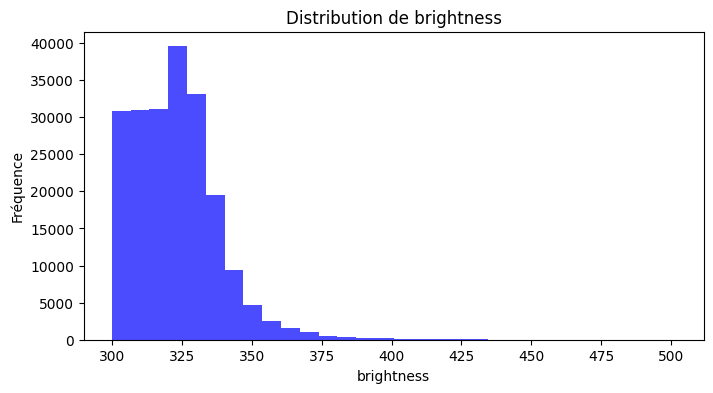

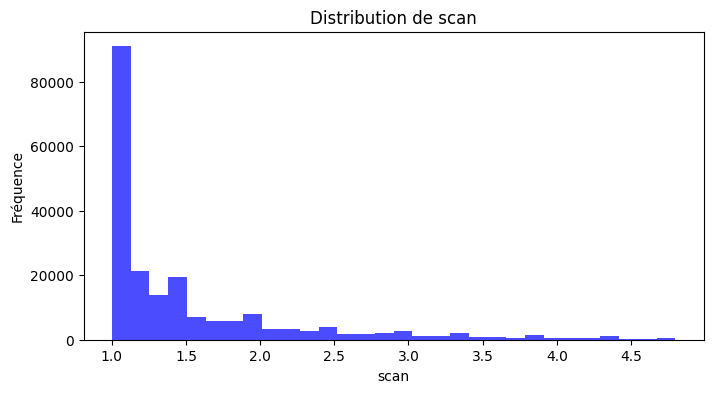

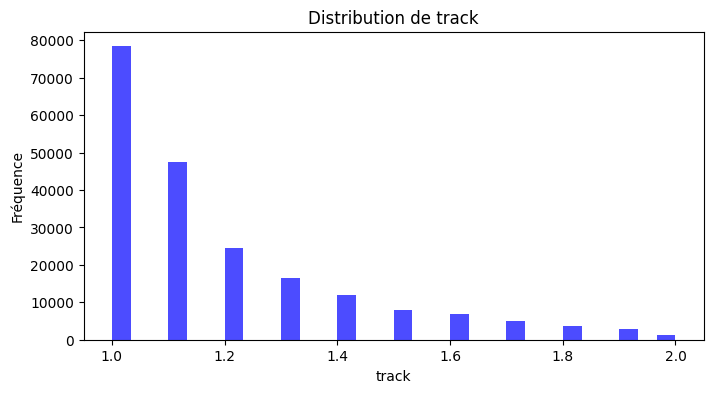

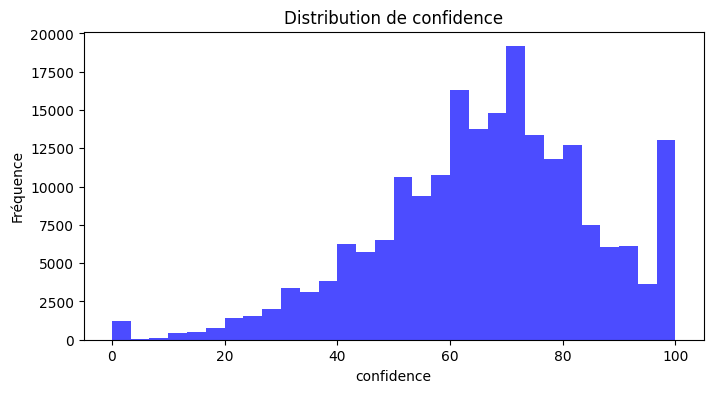

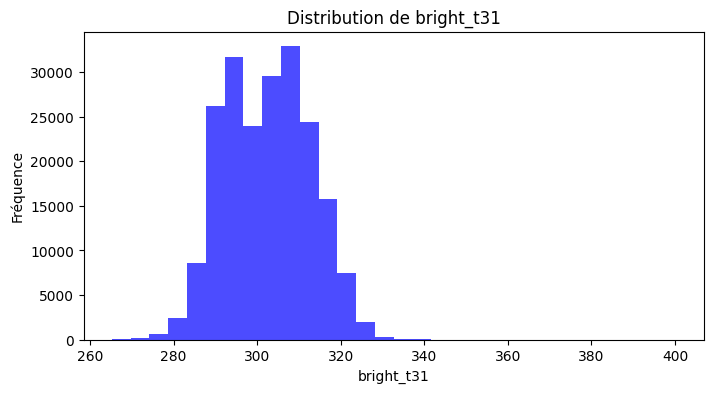

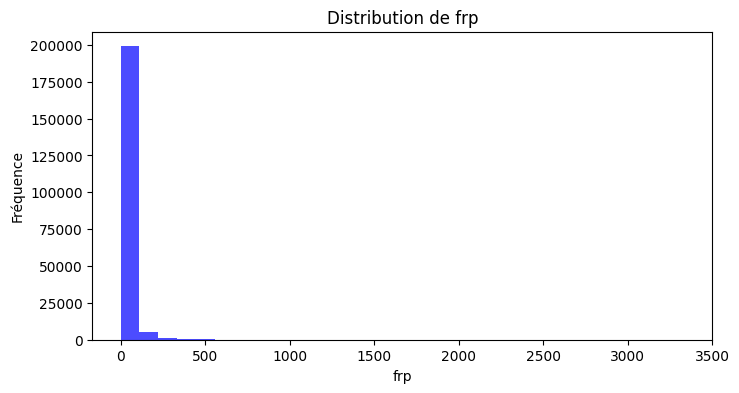

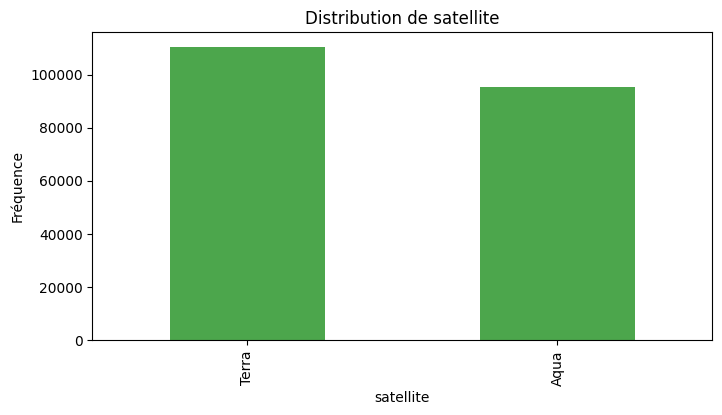


Valeurs uniques pour satellite:
['Terra' 'Aqua']


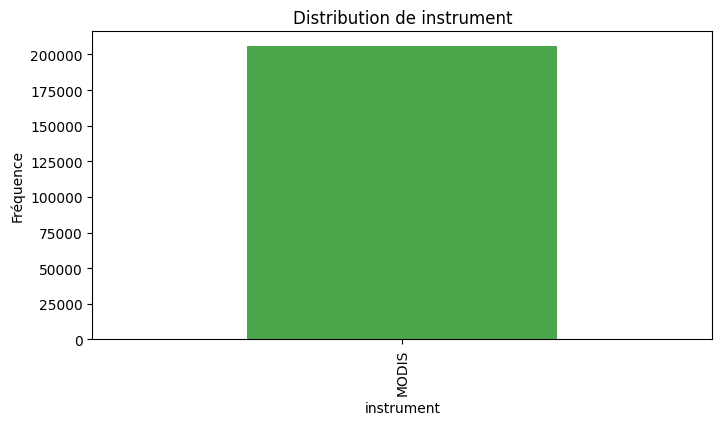


Valeurs uniques pour instrument:
['MODIS']


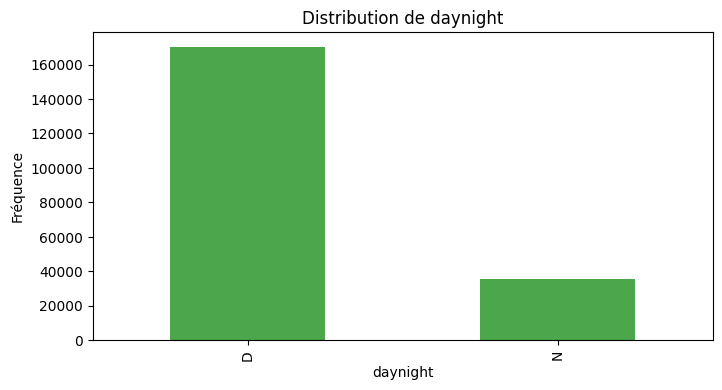


Valeurs uniques pour daynight:
['D' 'N']


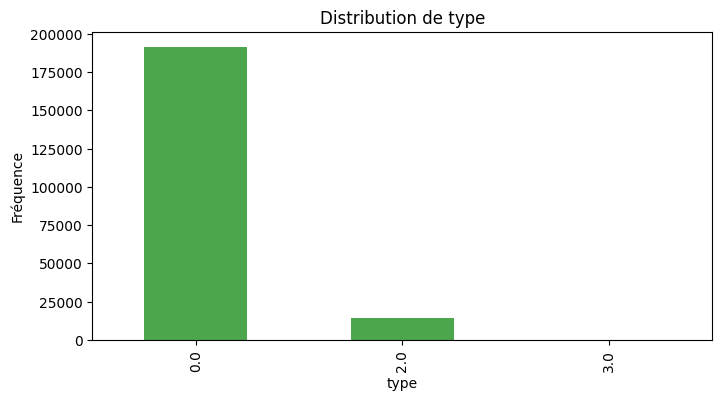


Valeurs uniques pour type:
[0. 2. 3.]


In [43]:
# Visualisation des variables quantitatives
# Les variables quantitatives sont des nombres qui peuvent être mesurés, comme la température ou la taille.
quantitative_columns = ['brightness', 'scan', 'track', 'confidence', 'bright_t31', 'frp']

# Pour chaque variable quantitative, nous créons un histogramme pour voir comment les valeurs sont distribuées.
for col in quantitative_columns:
    plt.figure(figsize=(8, 4))
    plt.hist(df_cleaned[col], bins=30, color='blue', alpha=0.7)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.show()

# Visualisation des variables qualitatives
# Les variables qualitatives sont des catégories, comme les types de satellites ou les instruments.
qualitative_columns = ['satellite', 'instrument', 'daynight', 'type']

# Pour chaque variable qualitative, nous créons un graphique à barres pour voir la répartition des catégories.
for col in qualitative_columns:
    plt.figure(figsize=(8, 4))
    df_cleaned[col].value_counts().plot(kind='bar', color='green', alpha=0.7)
    plt.title(f'Distribution de {col}')
    plt.xlabel(col)
    plt.ylabel('Fréquence')
    plt.show()

    # Afficher les valeurs uniques pour chaque variable qualitative
    # Cela nous montre quelles catégories existent dans chaque colonne.
    print(f"\nValeurs uniques pour {col}:")
    print(df_cleaned[col].unique())


In [44]:
# Préparation des données
# Nous sélectionnons les colonnes qui seront utilisées pour faire des prédictions (features) et la colonne que nous voulons prédire (type).
features = ['latitude', 'longitude', 'brightness', 'scan', 'track', 'confidence', 'bright_t31', 'frp', 'satellite', 'instrument', 'daynight']
df_known = df_cleaned[df_cleaned['type'].notna()]
df_unknown = df_cleaned[df_cleaned['type'].isna()]
X = df_known[features]
y = df_known['type']

# Encodage des variables catégorielles
# Les modèles de machine learning ne peuvent traiter que des nombres, donc nous devons convertir les catégories en nombres.
encoder = OneHotEncoder(drop='first', sparse_output=False)
X_encoded = encoder.fit_transform(X[['satellite', 'instrument', 'daynight']])
encoded_feature_names = encoder.get_feature_names_out(['satellite', 'instrument', 'daynight'])

# Combiner les variables numériques et catégorielles
X_numeric = X.drop(['satellite', 'instrument', 'daynight'], axis=1).reset_index(drop=True)
X_final = pd.concat([X_numeric, pd.DataFrame(X_encoded, columns=encoded_feature_names)], axis=1)

# Division des données
# Nous divisons les données en un ensemble d'entraînement (pour apprendre) et un ensemble de test (pour évaluer).
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)


c:\Users\amaur\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:317: UserWarning: The total space of parameters 2 is smaller than n_iter=10. Running 2 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 2 candidates, totalling 6 fits

Scores de validation croisée : [0.96900495 0.9701517  0.96973284]
Score moyen de validation croisée : 0.9696298312727057

Précision du modèle : 0.9711538461538461

Rapport de classification :
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.98     38353
         2.0       0.92      0.64      0.75      2814
         3.0       1.00      0.29      0.45        17

    accuracy                           0.97     41184
   macro avg       0.97      0.64      0.73     41184
weighted avg       0.97      0.97      0.97     41184



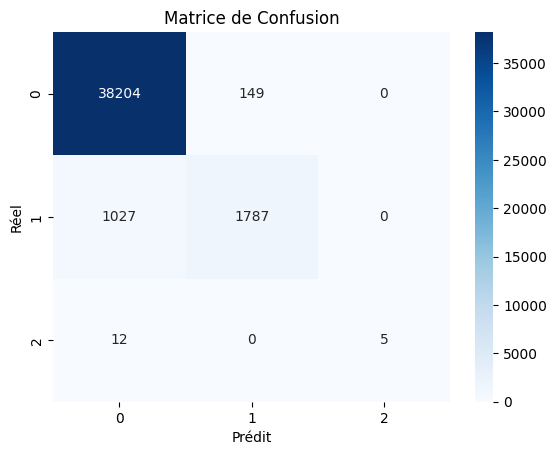

In [45]:
# Définir une grille de paramètres plus petite
# Nous réduisons le nombre de valeurs testées pour chaque hyperparamètre afin de rendre la recherche plus rapide.
param_dist = {
    'n_estimators': [100],  # Nombre d'arbres dans la forêt, réduit à une seule valeur pour accélérer la recherche
    'max_depth': [None, 10],  # Profondeur maximale d'un arbre, avec deux options : aucune limite ou 10
    'min_samples_split': [2],  # Nombre minimum d'échantillons requis pour diviser un nœud, réduit à une seule valeur
    'min_samples_leaf': [1]    # Nombre minimum d'échantillons requis pour être à une feuille, réduit à une seule valeur
}

# Utiliser RandomizedSearchCV pour une recherche plus rapide
# RandomizedSearchCV teste un nombre fixe de combinaisons aléatoires d'hyperparamètres.
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),  # Modèle à optimiser
    param_distributions=param_dist,  # Grille de paramètres à tester
    n_iter=10,  # Nombre de combinaisons aléatoires à tester
    cv=3,  # Nombre de folds pour la validation croisée, réduit pour accélérer le processus
    n_jobs=-1,  # Utiliser tous les cœurs de processeur disponibles pour le calcul
    verbose=2   # Niveau de verbosité pour afficher les détails de la recherche
)

# Ajuster le modèle
# La méthode fit() est utilisée pour effectuer la recherche des hyperparamètres sur les données d'entraînement.
random_search.fit(X_train, y_train)

# Meilleur modèle
# Le meilleur modèle trouvé par la recherche est stocké dans best_estimator_.
best_model = random_search.best_estimator_

# Validation croisée
# Nous évaluons le meilleur modèle en utilisant la validation croisée pour obtenir des scores de performance.
cv_scores = cross_val_score(best_model, X_train, y_train, cv=3)
print("\nScores de validation croisée :", cv_scores)
print("Score moyen de validation croisée :", sum(cv_scores) / len(cv_scores))

# Évaluation du modèle
# Nous utilisons le modèle pour faire des prédictions sur les données de test et comparons les résultats aux valeurs réelles.
y_pred = best_model.predict(X_test)
print("\nPrécision du modèle :", accuracy_score(y_test, y_pred))
print("\nRapport de classification :")
print(classification_report(y_test, y_pred))

# Matrice de confusion
# La matrice de confusion montre combien de prédictions correctes et incorrectes ont été faites pour chaque catégorie.
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()


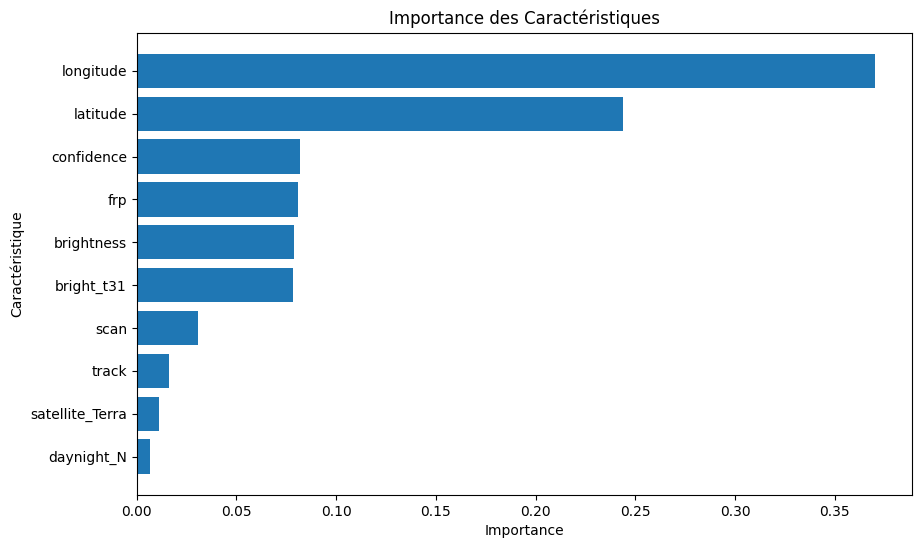

In [46]:
# Interprétabilité du modèle avec l'importance des caractéristiques
# Nous utilisons les fonctionnalités intégrées de scikit-learn pour obtenir l'importance des caractéristiques.

# Extraire l'importance des caractéristiques du modèle
# L'attribut feature_importances_ d'un modèle RandomForestClassifier contient l'importance de chaque caractéristique.
importances = best_model.feature_importances_

# Créer un DataFrame pour visualiser l'importance des caractéristiques
# Un DataFrame est utilisé pour organiser les noms des caractéristiques et leurs importances respectives.
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,  # Noms des caractéristiques
    'Importance': importances    # Valeurs d'importance correspondantes
})

# Trier les caractéristiques par ordre d'importance décroissant
# Cela permet de voir facilement quelles caractéristiques sont les plus importantes pour le modèle.
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualiser l'importance des caractéristiques
# Un graphique à barres horizontales est utilisé pour visualiser l'importance des caractéristiques.
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'])
plt.xlabel('Importance')  # Étiquette de l'axe des abscisses
plt.ylabel('Caractéristique')  # Étiquette de l'axe des ordonnées
plt.title('Importance des Caractéristiques')  # Titre du graphique
plt.gca().invert_yaxis()  # Inverser l'axe y pour avoir la caractéristique la plus importante en haut
plt.show()  # Afficher le graphique


In [47]:
# Prédiction des types manquants
# Si certaines données n'ont pas de type défini, nous utilisons le modèle pour prédire ces types.

# Vérifier si le DataFrame df_unknown contient des données sans type défini
if not df_unknown.empty:

    # Définir les caractéristiques (features) qui seront utilisées pour la prédiction
    # Ces caractéristiques sont les colonnes qui contiennent des informations pertinentes pour prédire le type.
    features = ["latitude", "longitude", "brightness", "scan", "track", "confidence", "bright_t31", "frp"]

    # Séparer les caractéristiques et la cible (type) pour les données connues
    X = df_known[features]
    y = df_known["type"]

    # Diviser les données connues en ensembles d'entraînement et de test
    # Cela permet d'entraîner le modèle sur une partie des données et de le tester sur une autre partie.
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Créer et entraîner un modèle RandomForestClassifier
    # Ce modèle est utilisé pour prédire les types manquants.
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # Utiliser les caractéristiques des données sans type défini pour prédire les types manquants
    X_unknown = df_unknown[features]
    predicted_types = model.predict(X_unknown)

    # Ajouter les types prédits dans la colonne 'type' du DataFrame df_unknown
    df_unknown.loc[:, "type"] = predicted_types

    # Combiner les données connues et les données avec les types prédits
    df_final = pd.concat([df_known, df_unknown], axis=0)

else:
    # Si df_unknown est vide, cela signifie qu'il n'y a pas de types manquants à prédire
    df_final = df_known

# Afficher la distribution des types après avoir prédit les types manquants
type_distribution_final = df_final["type"].value_counts()
print(type_distribution_final)


type
0.0    191670
2.0     14163
3.0        85
Name: count, dtype: int64


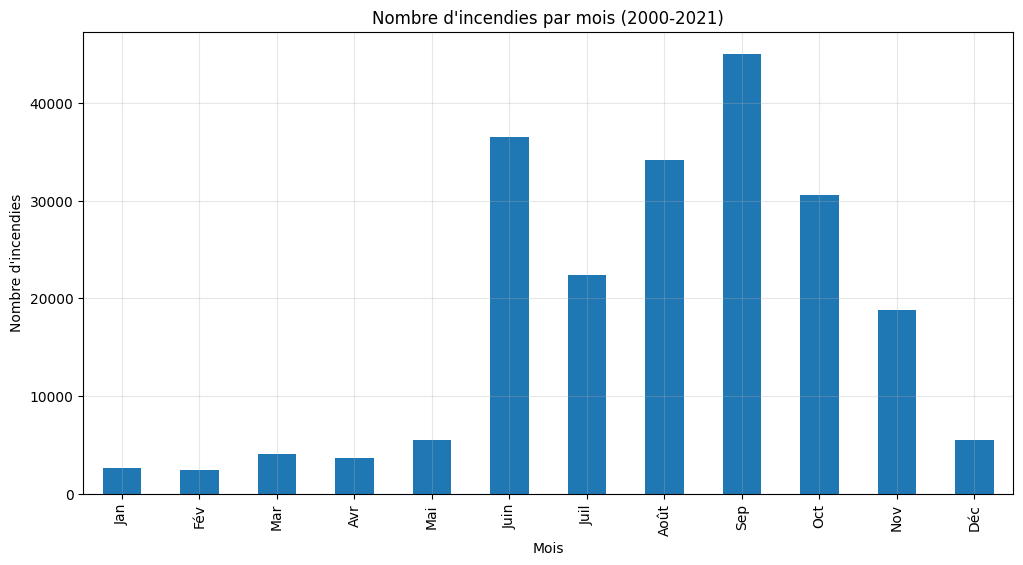

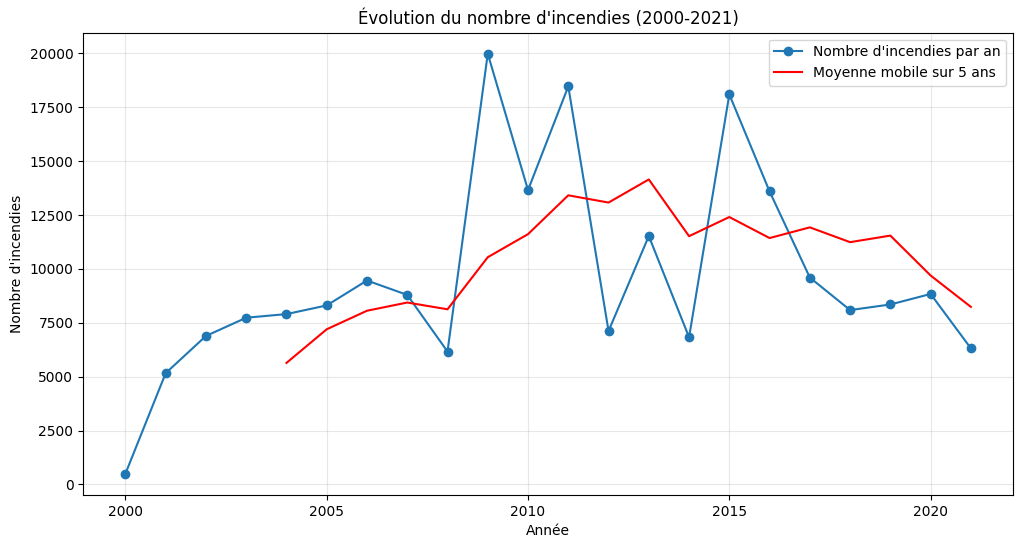

In [48]:
# Analyse temporelle
# Nous analysons comment les incendies sont répartis dans le temps (par mois et par année).

# Convertir la colonne 'acq_date' en format datetime
# Cela permet de manipuler les dates plus facilement et d'extraire le mois et l'année.
df["acq_date"] = pd.to_datetime(df["acq_date"])

# Extraire le mois de la date d'acquisition et créer une nouvelle colonne 'month'
df['month'] = df["acq_date"].dt.month

# Extraire l'année de la date d'acquisition et créer une nouvelle colonne 'year'
df['year'] = df["acq_date"].dt.year

# Calculer le nombre d'incendies par mois
# Nous utilisons groupby pour regrouper les données par mois et size pour compter le nombre d'incendies.
monthly_fires = df.groupby('month').size()

# Créer un graphique à barres pour visualiser le nombre d'incendies par mois
plt.figure(figsize=(12, 6))
monthly_fires.plot(kind='bar')
plt.title('Nombre d\'incendies par mois (2000-2021)')
plt.xlabel('Mois')
plt.ylabel('Nombre d\'incendies')

# Définir les étiquettes des mois pour l'axe des abscisses
plt.xticks(range(12), ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc'])

# Ajouter une grille pour améliorer la lisibilité du graphique
plt.grid(True, alpha=0.3)

# Afficher le graphique
plt.show()

# Calculer le nombre d'incendies par année
# Nous utilisons groupby pour regrouper les données par année et size pour compter le nombre d'incendies.
yearly_fires = df.groupby('year').size()

# Calculer la moyenne mobile sur 5 ans pour lisser les données et identifier les tendances
rolling_mean = yearly_fires.rolling(window=5).mean()

# Créer un graphique linéaire pour visualiser le nombre d'incendies par année et la moyenne mobile
plt.figure(figsize=(12, 6))
yearly_fires.plot(kind='line', marker='o', label='Nombre d\'incendies par an')
rolling_mean.plot(kind='line', color='red', label='Moyenne mobile sur 5 ans')
plt.title('Évolution du nombre d\'incendies (2000-2021)')
plt.xlabel('Année')
plt.ylabel('Nombre d\'incendies')

# Ajouter une grille pour améliorer la lisibilité du graphique
plt.grid(True, alpha=0.3)

# Ajouter une légende pour distinguer les deux séries de données
plt.legend()

# Afficher le graphique
plt.show()


Colonne 'brightness_category' créée avec succès.
Nombre de points pour Zone 1 : 201915
Nombre de points pour Zone 2 : 8838
Nombre de points pour Zone 3 : 504
Nombre de points pour Zone 4 : 52
Latitude min/max : 35.8221 42.033
Longitude min/max : 25.7236 44.7967
Brightness min/max : 300.0 503.53
Année 2000: 496 incendies détectés
Année 2001: 5162 incendies détectés
Année 2002: 6886 incendies détectés
Année 2003: 7733 incendies détectés
Année 2004: 7901 incendies détectés
Année 2005: 8303 incendies détectés
Année 2006: 9459 incendies détectés
Année 2007: 8791 incendies détectés
Année 2008: 6164 incendies détectés
Année 2009: 19979 incendies détectés
Année 2010: 13653 incendies détectés
Année 2011: 18465 incendies détectés
Année 2012: 7115 incendies détectés
Année 2013: 11521 incendies détectés
Année 2014: 6825 incendies détectés
Année 2015: 18089 incendies détectés
Année 2016: 13591 incendies détectés
Année 2017: 9596 incendies détectés
Année 2018: 8087 incendies détectés
Année 2019: 834

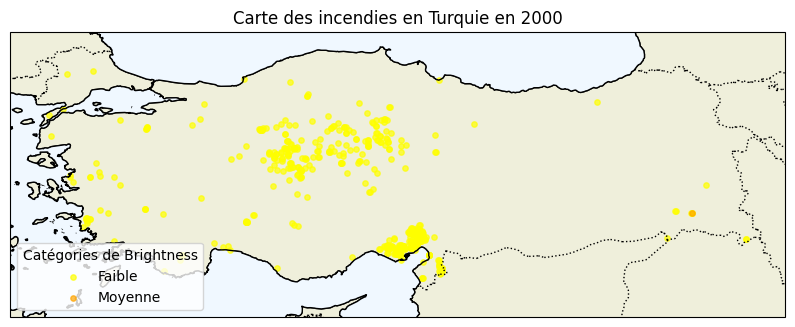

Année 2001: 5162 incendies détectés
Catégories présentes pour 2001: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2001


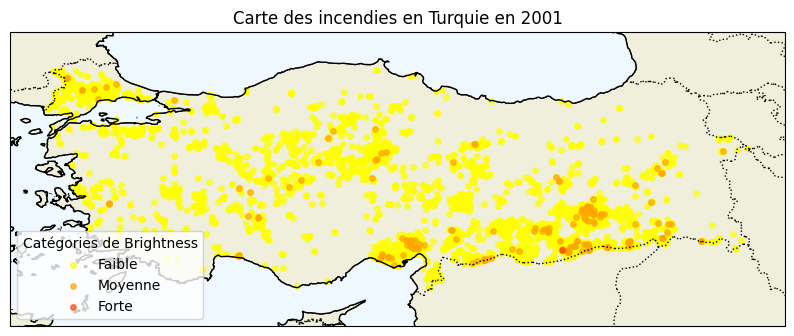

Année 2002: 6886 incendies détectés
Catégories présentes pour 2002: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


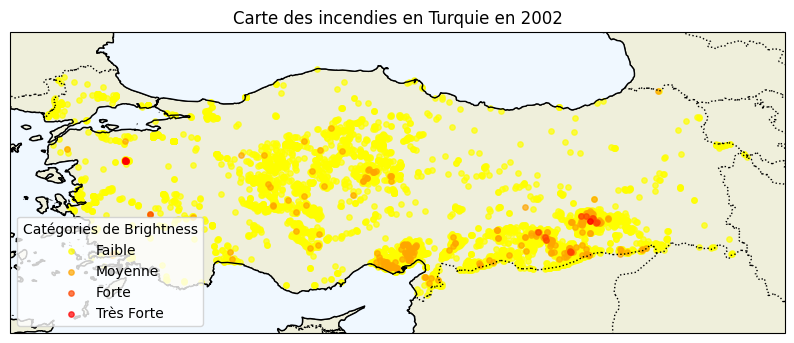

Année 2003: 7733 incendies détectés
Catégories présentes pour 2003: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2003


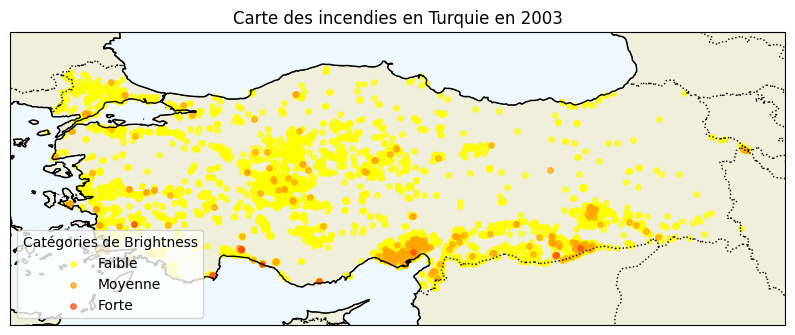

Année 2004: 7901 incendies détectés
Catégories présentes pour 2004: ['Faible', 'Moyenne', 'Très Forte', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


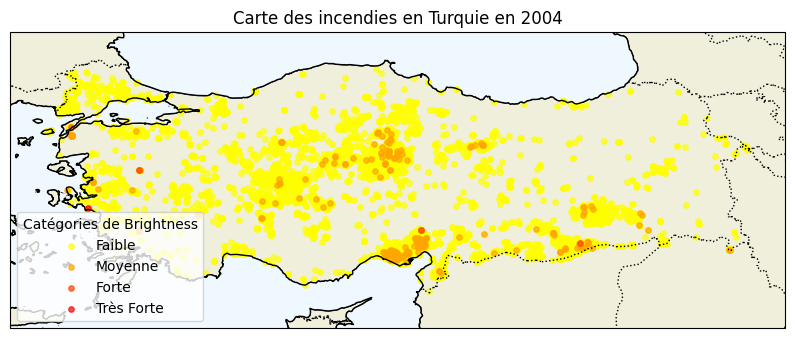

Année 2005: 8303 incendies détectés
Catégories présentes pour 2005: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


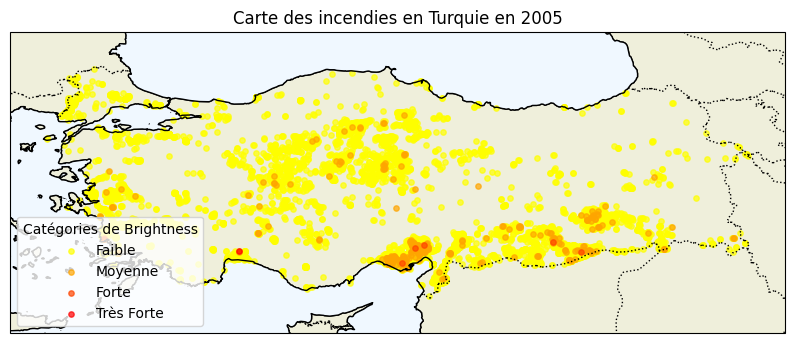

Année 2006: 9459 incendies détectés
Catégories présentes pour 2006: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2006


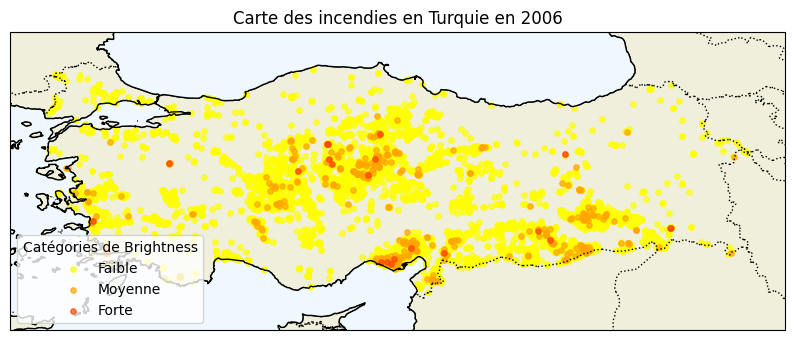

Année 2007: 8791 incendies détectés
Catégories présentes pour 2007: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


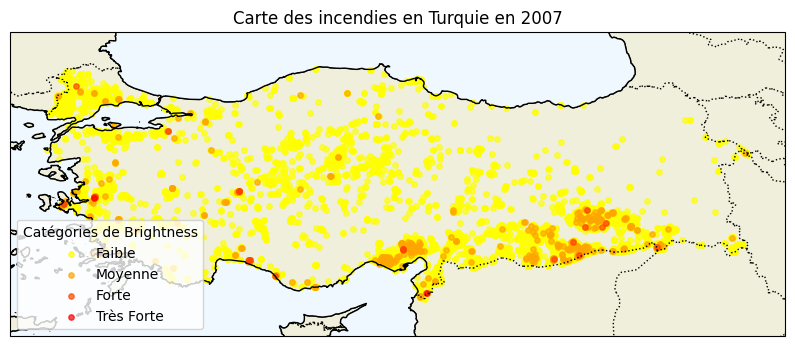

Année 2008: 6164 incendies détectés
Catégories présentes pour 2008: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


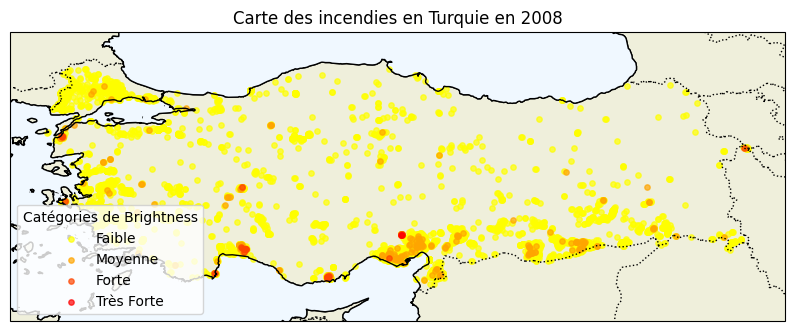

Année 2009: 19979 incendies détectés
Catégories présentes pour 2009: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2009


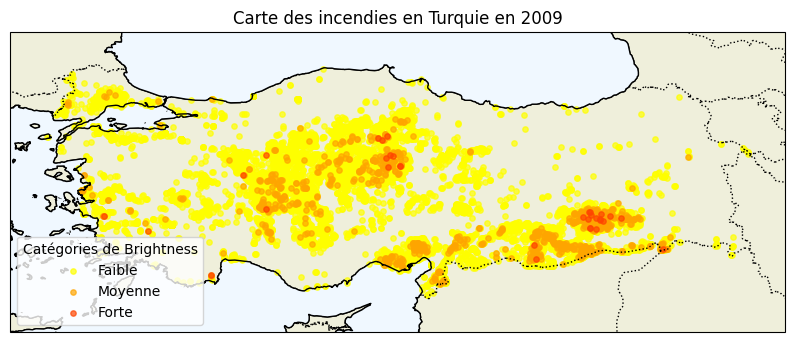

Année 2010: 13653 incendies détectés
Catégories présentes pour 2010: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


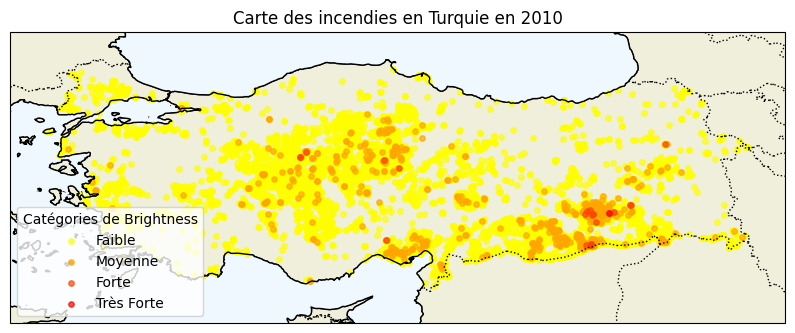

Année 2011: 18465 incendies détectés
Catégories présentes pour 2011: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


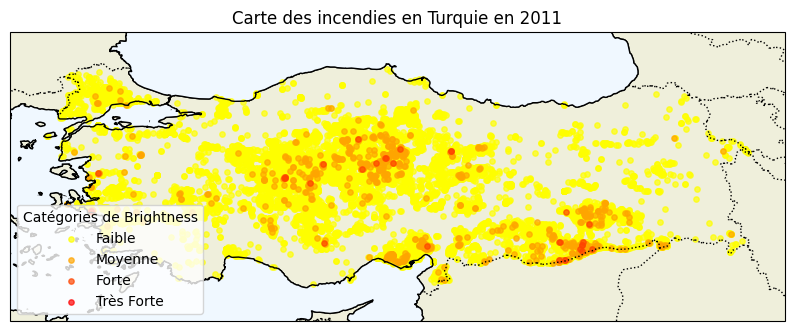

Année 2012: 7115 incendies détectés
Catégories présentes pour 2012: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


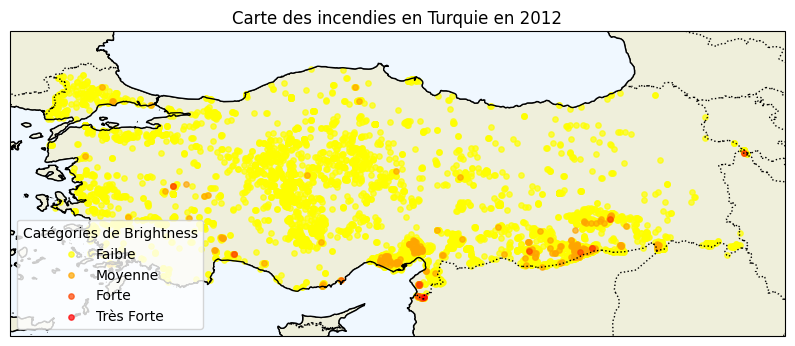

Année 2013: 11521 incendies détectés
Catégories présentes pour 2013: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


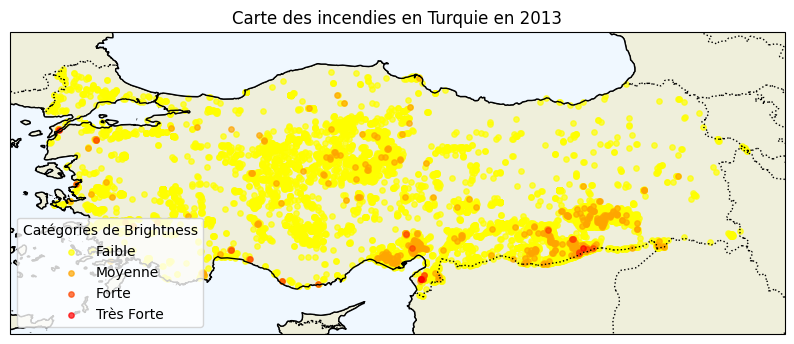

Année 2014: 6825 incendies détectés
Catégories présentes pour 2014: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2014


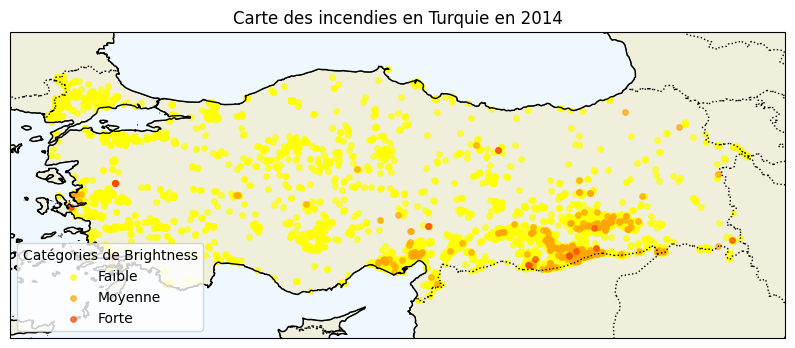

Année 2015: 18089 incendies détectés
Catégories présentes pour 2015: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


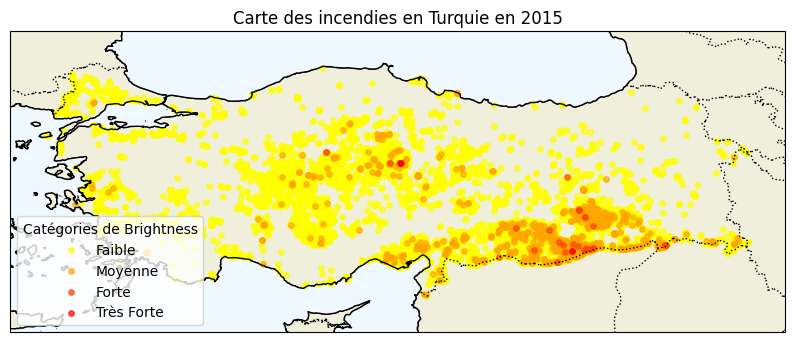

Année 2016: 13591 incendies détectés
Catégories présentes pour 2016: ['Moyenne', 'Faible', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


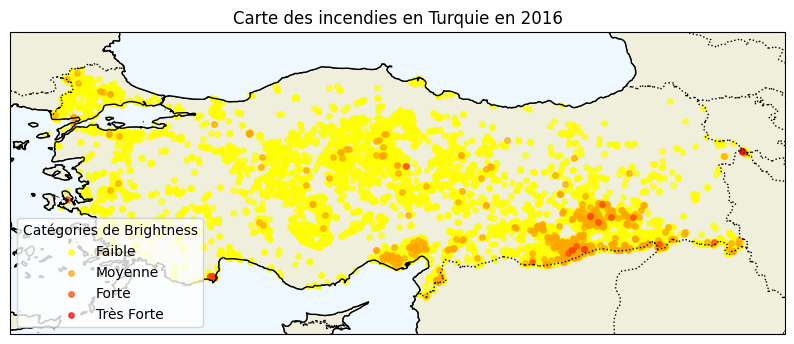

Année 2017: 9596 incendies détectés
Catégories présentes pour 2017: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2017


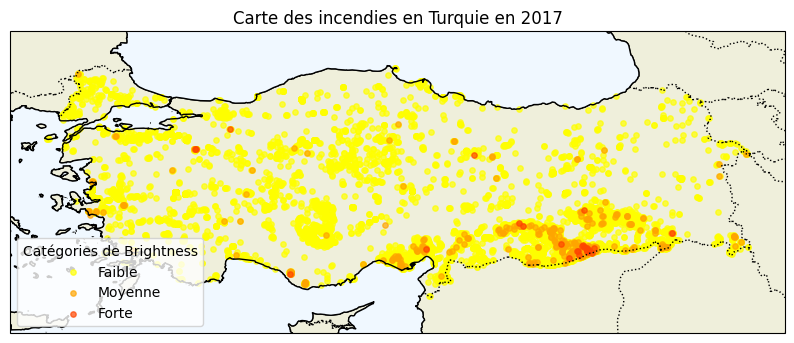

Année 2018: 8087 incendies détectés
Catégories présentes pour 2018: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2018


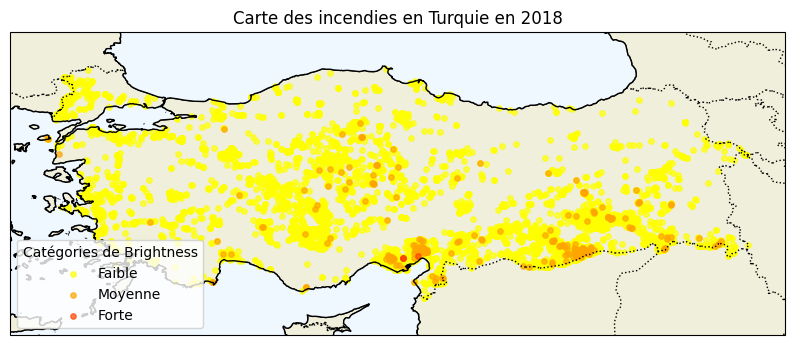

Année 2019: 8347 incendies détectés
Catégories présentes pour 2019: ['Faible', 'Moyenne', 'Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']
⚠️ Aucune donnée pour Très Forte en 2019


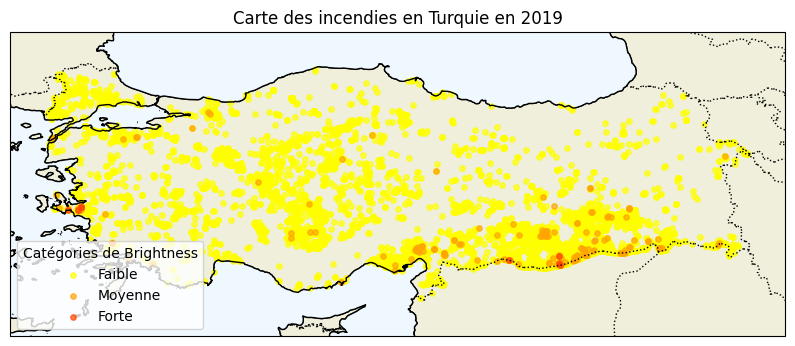

Année 2020: 8834 incendies détectés
Catégories présentes pour 2020: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


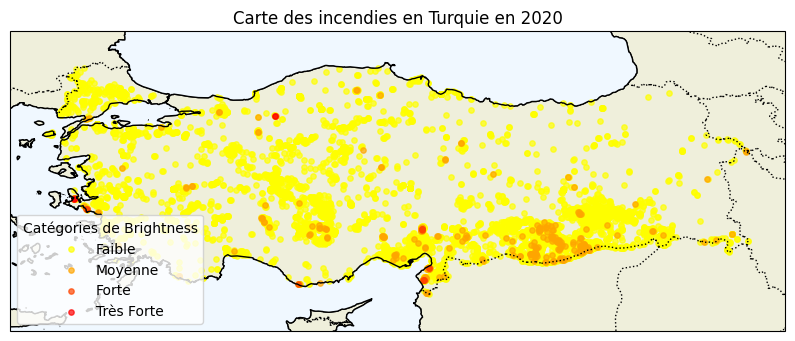

Année 2021: 6312 incendies détectés
Catégories présentes pour 2021: ['Faible', 'Moyenne', 'Forte', 'Très Forte']
Categories (4, object): ['Faible' < 'Moyenne' < 'Forte' < 'Très Forte']


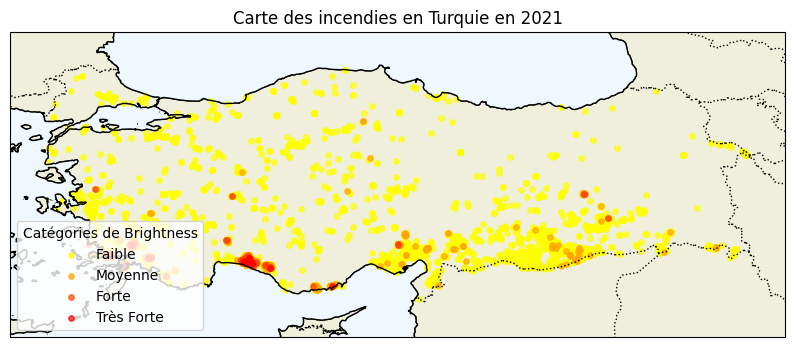

In [49]:
# Convertir la colonne 'acq_date' en format datetime
# Cela permet de manipuler les dates plus facilement.
df["acq_date"] = pd.to_datetime(df["acq_date"])

# Extraire l'année de la colonne 'acq_date'
# Nous créons une nouvelle colonne 'year' pour stocker l'année de chaque entrée.
df["year"] = df["acq_date"].dt.year

# Définir les années disponibles dans le DataFrame
# Nous obtenons une liste triée des années uniques présentes dans les données.
years = sorted(df["year"].unique())

# Vérifier si la colonne 'brightness' existe dans le DataFrame
if 'brightness' in df.columns:
    # Définir le nombre de catégories pour l'intensité des incendies
    num_categories = 4

    # Calculer les limites des catégories basées sur les valeurs minimales et maximales de 'brightness'
    frp_min = df['brightness'].min()
    frp_max = df['brightness'].max()
    category_ranges = np.linspace(frp_min, frp_max, num_categories + 1)

    # Créer les catégories pour 'brightness'
    categories = [f'Zone {i + 1}' for i in range(num_categories)]

    # Assigner une catégorie à chaque point de données en fonction de sa valeur de 'brightness'
    df['brightness_category'] = pd.cut(df['brightness'], bins=category_ranges, labels=categories, include_lowest=True)

    print("Colonne 'brightness_category' créée avec succès.")
else:
    print("Erreur : La colonne 'brightness' n'existe pas dans le DataFrame.")

# Vérification des données dans les catégories
# Afficher le nombre de points de données dans chaque catégorie de 'brightness'
for category in categories:
    print(f"Nombre de points pour {category} : {len(df[df['brightness_category'] == category])}")

# Vérification des données de latitude et longitude
# Afficher les valeurs minimales et maximales pour la latitude et la longitude
print("Latitude min/max :", df['latitude'].min(), df['latitude'].max())
print("Longitude min/max :", df['longitude'].min(), df['longitude'].max())
print("Brightness min/max :", df['brightness'].min(), df['brightness'].max())

# Vérifier qu'il y a bien des incendies pour chaque année
# Boucle sur les années de 2000 à 2021 pour afficher le nombre d'incendies détectés chaque année
for year in range(2000, 2022):
    df_year = df[df['year'] == year]  # Filtrer les données de l'année
    print(f"Année {year}: {len(df_year)} incendies détectés")  # Afficher le nombre d'incendies

# Assurer que les années sont en format entier
df['year'] = df['year'].astype(int)

# Mapping des catégories pour qu'elles correspondent à des descriptions textuelles
category_mapping = {
    "Zone 1": "Faible",
    "Zone 2": "Moyenne",
    "Zone 3": "Forte",
    "Zone 4": "Très Forte"
}
df['brightness_category'] = df['brightness_category'].map(category_mapping)

# Définir les couleurs pour chaque catégorie
colors = ["yellow", "orange", "orangered", "red"]
categories = ["Faible", "Moyenne", "Forte", "Très Forte"]

# Création de cartes pour chaque année
for year in years:
    df_year = df[df['year'] == year]

    print(f"Année {year}: {len(df_year)} incendies détectés")
    if df_year.empty:
        print(f"⚠️ Pas d'incendies pour {year}, on passe à l'année suivante.")
        continue

    print(f"Catégories présentes pour {year}:", df_year['brightness_category'].unique())

    # Création de la carte
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Ajustement de la zone en fonction des incendies présents
    if not df_year.empty:
        ax.set_extent([df_year['longitude'].min() - 1, df_year['longitude'].max() + 1,
                       df_year['latitude'].min() - 1, df_year['latitude'].max() + 1],
                       crs=ccrs.PlateCarree())

    # Ajouter les éléments de la carte
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor="black")
    ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")

    # Ajouter les feux sur la carte
    for category, color in zip(categories, colors):
        category_data = df_year[df_year['brightness_category'] == category]
        if category_data.empty:
            print(f"⚠️ Aucune donnée pour {category} en {year}")
            continue
        ax.scatter(category_data['longitude'], category_data['latitude'],
                   transform=ccrs.PlateCarree(), s=15, alpha=0.7, color=color, label=category)

    plt.legend(title="Catégories de Brightness", loc="lower left")
    plt.title(f'Carte des incendies en Turquie en {year}')

    plt.show()


In [51]:
# Visualisation géographique
# Nous créons une carte interactive pour montrer où les incendies se sont produits.

# Filtrer les données pour ne garder que les incendies avec une confiance supérieure à 90%
# Cela permet de se concentrer sur les données les plus fiables.
df_filtered = df_cleaned[df_cleaned['confidence'] > 90]

# Convertir la colonne 'acq_date' en format datetime pour faciliter la manipulation des dates
df_filtered['acq_date'] = pd.to_datetime(df_filtered['acq_date'])

# Extraire l'année de la date d'acquisition et créer une nouvelle colonne 'year'
df_filtered['year'] = df_filtered['acq_date'].dt.year

# Créer une carte centrée sur la Turquie avec un niveau de zoom initial de 6
m = folium.Map(location=[39, 35], zoom_start=6)

# Créer un dictionnaire pour stocker les groupes de marqueurs par année
year_groups = {}

# Parcourir chaque année unique dans les données filtrées
for year in df_filtered['year'].unique():
    # Créer un groupe de marqueurs pour chaque année
    cluster = MarkerCluster(name=f"Incendies {year}").add_to(m)

    # Filtrer les données pour l'année actuelle
    df_year = df_filtered[df_filtered['year'] == year]

    # Ajouter chaque incendie à la carte sous forme de marqueur
    for _, row in df_year.iterrows():
        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],  # Position du marqueur
            radius=4,  # Rayon du marqueur
            color='red',  # Couleur de la bordure
            fill=True,  # Remplir le marqueur
            fill_color='red',  # Couleur de remplissage
            fill_opacity=0.6,  # Opacité du remplissage
            popup=f"Année: {year}, Confiance: {row['confidence']}"  # Informations affichées lors du clic
        ).add_to(cluster)  # Ajouter le marqueur au groupe de l'année

# Ajouter un contrôle de couches pour activer/désactiver les groupes de marqueurs
folium.LayerControl(collapsed=False).add_to(m)

# Enregistrer la carte interactive sous forme de fichier HTML
m.save("fire_map_by_year_clustered.html")
print("✅ Carte interactive enregistrée sous 'fire_map_by_year_clustered.html'.")


C:\Users\amaur\AppData\Local\Temp\ipykernel_21716\1615784581.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['acq_date'] = pd.to_datetime(df_filtered['acq_date'])
C:\Users\amaur\AppData\Local\Temp\ipykernel_21716\1615784581.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['year'] = df_filtered['acq_date'].dt.year


✅ Carte interactive enregistrée sous 'fire_map_by_year_clustered.html'.
